# Heart Disease Prediction — EE344 Final Project

**Authors:** Liam Lin, Haochen Zhao, Anthony Li  

This notebook implements the pipeline described in our project proposal, incorporating:
- **Leakage-safe preprocessing:** All preprocessing (imputation, encoding, scaling, SMOTE) is done **inside a sklearn Pipeline**, fitted only on training folds during cross-validation.
- **Decision threshold tuning:** We tune the classification threshold to prioritize recall and report the precision–recall tradeoff.
- **Interpretability:** LR coefficients; permutation importance for tree-based models; short error analysis (FN vs FP).

**Dataset:** Heart Disease Dataset (Kaggle), 13 features, binary target.  
**Success criteria:** F1 > 0.85, ROC-AUC > 0.90, with emphasis on recall.

## 1. Imports and configuration

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings("ignore")

# Optional: SHAP for interpretability (install with: pip install shap)
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Path to dataset (adjust if needed)
DATA_PATH = os.path.join("dataset", "heart.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
TARGET_RECALL = 0.90  # Threshold tuning: aim for at least this recall

## 2. Load data and basic info

In [11]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nTarget distribution (0=no disease, 1=disease):")
print(df["target"].value_counts())
print("\nProportions:")
print(df["target"].value_counts(normalize=True))
df.head(10)

Shape: (1025, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Target distribution (0=no disease, 1=disease):
target
1    526
0    499
Name: count, dtype: int64

Proportions:
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [12]:
# Missing values and dtypes
print("Missing per column:")
print(df.isnull().sum())
print("\nDtypes:")
print(df.dtypes)
print("\nDescribe:")
df.describe()

Missing per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dtypes:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Describe:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

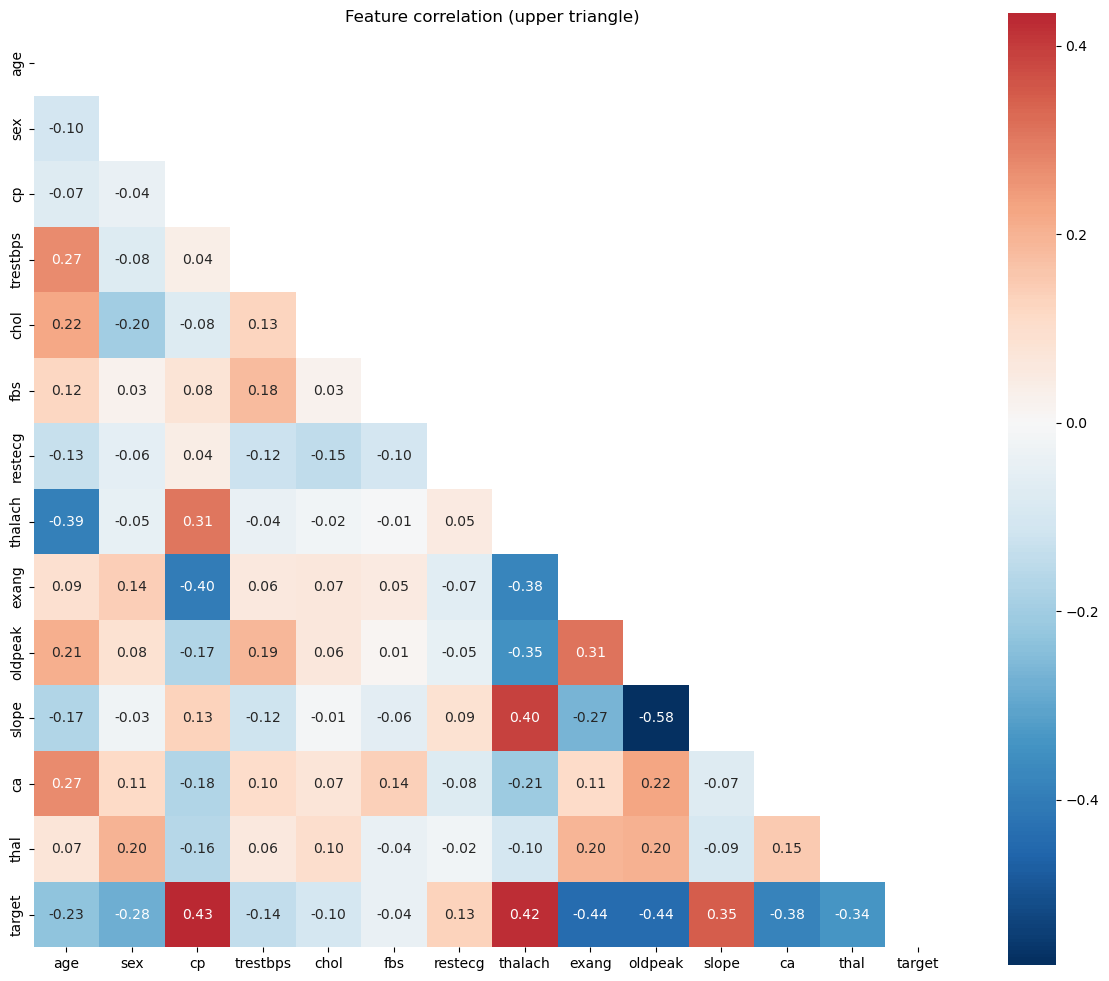

In [13]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Feature correlation (upper triangle)")
plt.tight_layout()
plt.show()

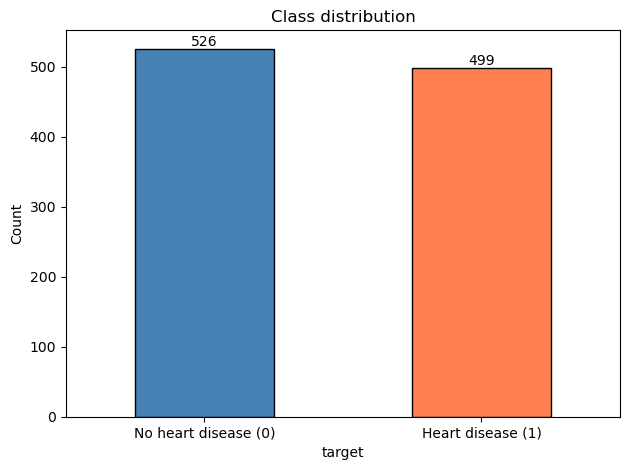

In [14]:
# Class balance
ax = df["target"].value_counts().plot(kind="bar", color=["steelblue", "coral"], edgecolor="black")
ax.set_xticklabels(["No heart disease (0)", "Heart disease (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class distribution")
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 4. Train/test split and feature columns

We use a **stratified 80/20 split** so that class proportions are preserved. All preprocessing and model fitting will use only the training set (and within CV, only the training fold) to avoid leakage.

In [15]:
# Feature columns: numeric (for scaling) and categorical (for one-hot if desired)
# Per proposal we use one-hot for cp, restecg, slope, thal. Rest are numeric.
NUMERIC_FEATURES = ["age", "sex", "trestbps", "chol", "fbs", "thalach", "exang", "oldpeak", "ca"]
CATEGORICAL_FEATURES = ["cp", "restecg", "slope", "thal"]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET_COL = "target"

X = df[FEATURE_COLUMNS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", len(X_train), "| Test size:", len(X_test))
print("Train target distribution:\n", y_train.value_counts())
print("\nTest target distribution:\n", y_test.value_counts())

Train size: 820 | Test size: 205
Train target distribution:
 target
1    421
0    399
Name: count, dtype: int64

Test target distribution:
 target
1    105
0    100
Name: count, dtype: int64


## 5. Leakage-safe preprocessing pipeline

All steps that learn from data are **inside a Pipeline** and fitted only on the training (or train-fold) data:
- **Imputation:** median for numeric, most_frequent for categorical (fit on train only).
- **Scaling:** StandardScaler on numeric features (fit on train only).
- **Encoding:** OneHotEncoder for categoricals (fit on train only).
- **SMOTE:** Applied only to the training data after transform (no test/fold data used).

We use `imblearn.pipeline.Pipeline` so that SMOTE runs inside cross-validation without leaking.

In [16]:
# Preprocessor: impute + scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")),
        ]), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

# Build full pipeline: preprocessor -> optional SMOTE -> classifier
# Use ImbPipeline so SMOTE is fitted only on training data in each CV fold
def make_pipeline(clf, use_smote=True):
    steps = [("preprocessor", preprocessor)]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)))
    steps.append(("classifier", clf))
    return ImbPipeline(steps)

# Model definitions (to be used inside pipeline)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE, class_weight="balanced", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, class_weight="balanced"),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE, early_stopping=True),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)

## 6. Cross-validation and test evaluation (leakage-safe)

We run **5-fold stratified CV** with the full pipeline (preprocessor + SMOTE + classifier). Each fold fits preprocessor and SMOTE only on that fold’s train split, then evaluates on the validation split. Then we fit the pipeline once on the full training set and evaluate on the held-out test set.

In [17]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_results = {}

for name, clf in models.items():
    pipe = make_pipeline(clf, use_smote=True)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_results[name] = {s: (scores[f"test_{s}"].mean(), scores[f"test_{s}"].std()) for s in scoring}
    print(f"{name}: F1 = {cv_results[name]['f1'][0]:.3f} ± {cv_results[name]['f1'][1]:.3f}  |  "
          f"Recall = {cv_results[name]['recall'][0]:.3f}  |  ROC-AUC = {cv_results[name]['roc_auc'][0]:.3f}")

Logistic Regression: F1 = 0.855 ± 0.029  |  Recall = 0.876  |  ROC-AUC = 0.924
SVM (RBF): F1 = 0.886 ± 0.017  |  Recall = 0.898  |  ROC-AUC = 0.968
Random Forest: F1 = 0.981 ± 0.021  |  Recall = 0.981  |  ROC-AUC = 0.998
MLP: F1 = 0.847 ± 0.021  |  Recall = 0.867  |  ROC-AUC = 0.906


In [18]:
# Fit each pipeline on full training set and evaluate on test set
test_metrics = {}
fitted_pipes = {}

for name, clf in models.items():
    pipe = make_pipeline(clf, use_smote=True)
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    test_metrics[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else None,
    }
    ra = test_metrics[name]['roc_auc']
    roc_str = f"{ra:.3f}" if ra is not None else "N/A"
    print(f"{name}: F1={test_metrics[name]['f1']:.3f}, Recall={test_metrics[name]['recall']:.3f}, ROC-AUC={roc_str}")

Logistic Regression: F1=0.870, Recall=0.924, ROC-AUC=0.926
SVM (RBF): F1=0.933, Recall=0.933, ROC-AUC=0.972
Random Forest: F1=1.000, Recall=1.000, ROC-AUC=1.000
MLP: F1=0.805, Recall=0.848, ROC-AUC=0.857


In [19]:
# Summary table: CV mean ± std and test metrics
summary = pd.DataFrame({
    "Model": list(models.keys()),
    "CV_F1_mean": [cv_results[n]["f1"][0] for n in models],
    "CV_F1_std": [cv_results[n]["f1"][1] for n in models],
    "CV_Recall": [cv_results[n]["recall"][0] for n in models],
    "CV_ROC_AUC": [cv_results[n]["roc_auc"][0] for n in models],
    "Test_F1": [test_metrics[n]["f1"] for n in models],
    "Test_Recall": [test_metrics[n]["recall"] for n in models],
    "Test_ROC_AUC": [test_metrics[n]["roc_auc"] or 0 for n in models],
})
summary

,Model,CV_F1_mean,CV_F1_std,CV_Recall,CV_ROC_AUC,Test_F1,Test_Recall,Test_ROC_AUC
0,Logistic Regression,0.855096,0.029360,0.876443,0.924364,0.869955,0.923810,0.926095
1,SVM (RBF),0.885691,0.017495,0.897843,0.967614,0.933333,0.933333,0.972476
2,Random Forest,0.980901,0.020648,0.980952,0.997798,1.000000,1.000000,1.000000
3,MLP,0.847009,0.021306,0.866891,0.905580,0.805430,0.847619,0.857429


## 7. Decision threshold tuning (clinical priority: recall)

We tune the classification threshold to **prioritize recall** (sensitivity) so that we miss fewer true heart-disease cases. We choose a threshold that achieves at least `TARGET_RECALL` (e.g. 0.90) and report the resulting precision and F1 at that threshold.

In [20]:
# Use the model with best test F1 (or pick one, e.g. Logistic Regression for interpretability)
best_model_name = max(test_metrics, key=lambda k: test_metrics[k]["f1"])
pipe_best = fitted_pipes[best_model_name]
y_proba_test = pipe_best.predict_proba(X_test)[:, 1]

# Sweep thresholds and find one that achieves at least TARGET_RECALL
thresholds = np.linspace(0.2, 0.8, 61)
recalls = []
precisions = []
f1s = []
for t in thresholds:
    y_t = (y_proba_test >= t).astype(int)
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    f1s.append(f1_score(y_test, y_t, zero_division=0))

# Choose threshold: first (highest) threshold where recall >= TARGET_RECALL
idx = next((i for i in range(len(thresholds)) if recalls[i] >= TARGET_RECALL), len(thresholds) - 1)
chosen_threshold = thresholds[idx]
print(f"Chosen threshold = {chosen_threshold:.2f} (target recall >= {TARGET_RECALL})")
print(f"At this threshold: Precision = {precisions[idx]:.3f}, Recall = {recalls[idx]:.3f}, F1 = {f1s[idx]:.3f}")

Chosen threshold = 0.20 (target recall >= 0.9)
At this threshold: Precision = 0.890, Recall = 1.000, F1 = 0.942


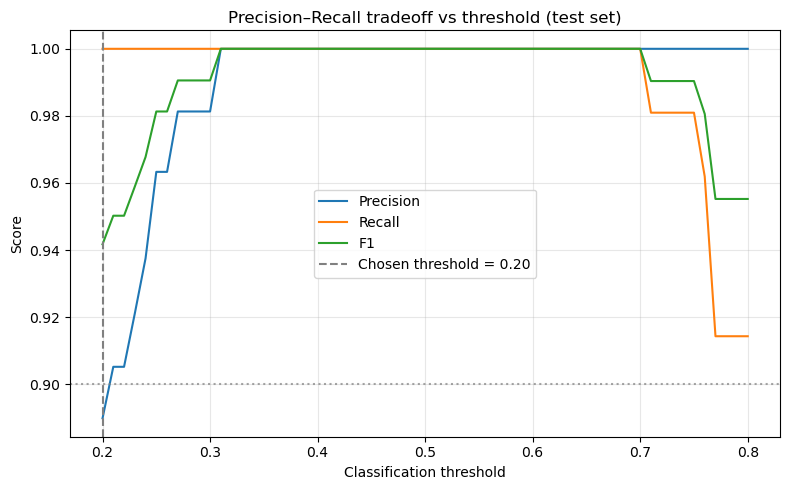

In [21]:
# Plot precision-recall tradeoff vs threshold
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, label="Precision", color="C0")
ax.plot(thresholds, recalls, label="Recall", color="C1")
ax.plot(thresholds, f1s, label="F1", color="C2")
ax.axvline(chosen_threshold, color="gray", linestyle="--", label=f"Chosen threshold = {chosen_threshold:.2f}")
ax.axhline(TARGET_RECALL, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score")
ax.set_title("Precision–Recall tradeoff vs threshold (test set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Interpretability

**Logistic Regression:** We report the coefficients (and optionally odds ratios) to see which features push the prediction toward heart disease.  
**Tree-based model (Random Forest):** We use **permutation importance** to rank features (and SHAP if available).

In [22]:
# Get feature names after preprocessing (numeric + one-hot categorical)
pipe_lr = fitted_pipes["Logistic Regression"]
ct = pipe_lr.named_steps["preprocessor"]
feature_names = ct.get_feature_names_out()

coef = pipe_lr.named_steps["classifier"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coef}).sort_values("coefficient", key=abs, ascending=False)
print("Logistic Regression coefficients (positive => more likely heart disease):")
print(coef_df.to_string(index=False))

Logistic Regression coefficients (positive => more likely heart disease):
       feature  coefficient
     cat__cp_2     1.862802
     cat__cp_3     1.551141
       num__ca    -0.812260
     cat__cp_1     0.751909
   cat__thal_2     0.743074
      num__sex    -0.651070
   cat__thal_3    -0.593377
  cat__slope_1    -0.518821
  num__oldpeak    -0.517100
   cat__thal_1     0.481669
    num__exang    -0.450749
  cat__slope_2     0.367420
cat__restecg_1     0.360691
  num__thalach     0.291580
 num__trestbps    -0.280684
     num__chol    -0.251847
cat__restecg_2    -0.222206
      num__age    -0.100180
      num__fbs     0.036653


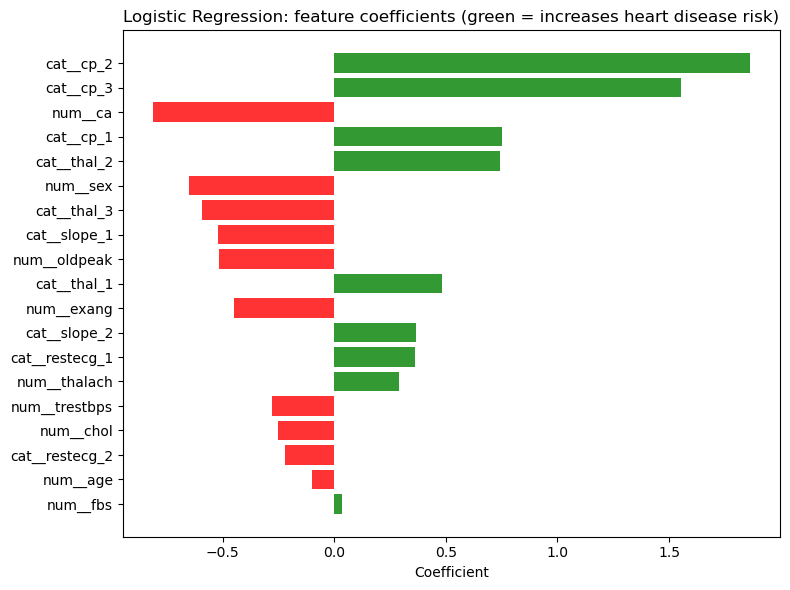

In [23]:
# Plot LR coefficients
plt.figure(figsize=(8, 6))
colors = ["green" if c > 0 else "red" for c in coef_df["coefficient"]]
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors, alpha=0.8)
plt.xlabel("Coefficient")
plt.title("Logistic Regression: feature coefficients (green = increases heart disease risk)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# Permutation importance for Random Forest (on test set, leakage-safe: model already fitted)
from sklearn.inspection import permutation_importance

pipe_rf = fitted_pipes["Random Forest"]
X_test_transformed = pipe_rf.named_steps["preprocessor"].transform(X_test)
perm = permutation_importance(
    pipe_rf.named_steps["classifier"], X_test_transformed, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=1
)
perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)
print("Random Forest permutation importance (test set):")
print(perm_df.to_string(index=False))

Random Forest permutation importance (test set):
       feature  importance_mean  importance_std
       num__ca         0.087317        0.013527
   cat__thal_2         0.036098        0.006617
  num__oldpeak         0.029268        0.005772
      num__age         0.019024        0.005540
 num__trestbps         0.018537        0.007494
     cat__cp_2         0.018049        0.007573
     num__chol         0.015122        0.004602
   cat__thal_3         0.013659        0.004779
      num__sex         0.012195        0.004497
  num__thalach         0.010732        0.008104
    num__exang         0.009268        0.004602
     cat__cp_3         0.007805        0.002390
      num__fbs         0.000000        0.000000
     cat__cp_1         0.000000        0.000000
cat__restecg_1         0.000000        0.000000
  cat__slope_1         0.000000        0.000000
cat__restecg_2         0.000000        0.000000
   cat__thal_1         0.000000        0.000000
  cat__slope_2         0.000000        

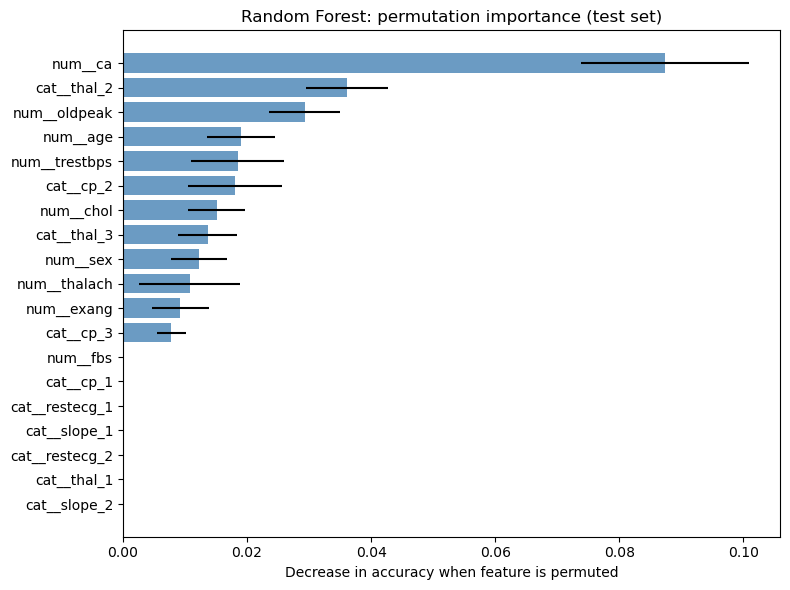

In [25]:
plt.figure(figsize=(8, 6))
plt.barh(perm_df["feature"], perm_df["importance_mean"], xerr=perm_df["importance_std"], color="steelblue", alpha=0.8)
plt.xlabel("Decrease in accuracy when feature is permuted")
plt.title("Random Forest: permutation importance (test set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Error analysis: false negatives vs false positives

We summarize **false negatives (FN)** — true heart disease missed by the model — and **false positives (FP)** — healthy patients predicted as disease. This helps identify which types of cases the model tends to get wrong.

In [26]:
# Predictions using default threshold 0.5 (or use chosen_threshold from section 7)
y_pred_best = (fitted_pipes[best_model_name].predict_proba(X_test)[:, 1] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print("Confusion matrix (test set, default threshold 0.5):")
print(f"  TN={tn}, FP={fp}")
print(f"  FN={fn}, TP={tp}")
print(f"\nFalse Negatives: {fn} (true heart disease missed) — {fn / (fn + tp) * 100:.1f}% of actual disease cases missed")
print(f"False Positives: {fp} (healthy predicted as disease) — {fp / (fp + tn) * 100:.1f}% of healthy predicted positive")

Confusion matrix (test set, default threshold 0.5):
  TN=100, FP=0
  FN=0, TP=105

False Negatives: 0 (true heart disease missed) — 0.0% of actual disease cases missed
False Positives: 0 (healthy predicted as disease) — 0.0% of healthy predicted positive


In [27]:
# Add prediction columns to test set for error analysis
X_test_copy = X_test.copy()
X_test_copy["true"] = y_test.values
X_test_copy["pred"] = y_pred_best
X_test_copy["FN"] = (X_test_copy["true"] == 1) & (X_test_copy["pred"] == 0)
X_test_copy["FP"] = (X_test_copy["true"] == 0) & (X_test_copy["pred"] == 1)
X_test_copy["TP"] = (X_test_copy["true"] == 1) & (X_test_copy["pred"] == 1)

fn_cases = X_test_copy[X_test_copy["FN"]]
tp_cases = X_test_copy[X_test_copy["TP"]]
fp_cases = X_test_copy[X_test_copy["FP"]]

# Compare mean feature values: FN vs TP (both are actually disease; FN was missed)
feats = FEATURE_COLUMNS
if len(fn_cases) > 0 and len(tp_cases) > 0:
    compare = pd.DataFrame({
        "FN_mean": fn_cases[feats].mean(),
        "TP_mean": tp_cases[feats].mean(),
        "diff": fn_cases[feats].mean() - tp_cases[feats].mean(),
    })
    print("Feature means: False Negatives vs True Positives (FN = missed disease):")
    print(compare.round(3).to_string())
else:
    print("No FN or no TP in test set; skip comparison.")

No FN or no TP in test set; skip comparison.


In [28]:
# Short summary for report
print("Error analysis summary:")
print(f"  - FN count: {fn} (critical: missed heart disease). Reducing threshold can lower FN but may increase FP.")
print(f"  - FP count: {fp} (healthy flagged; may lead to extra tests).")
if len(fn_cases) > 0 and len(tp_cases) > 0:
    print("  - FN cases vs TP: compare feature means above to see if certain subgroups are harder to detect.")

Error analysis summary:
  - FN count: 0 (critical: missed heart disease). Reducing threshold can lower FN but may increase FP.
  - FP count: 0 (healthy flagged; may lead to extra tests).


## 10. Optional: Ensemble (Voting classifier)

We combine the best-performing models using a soft voting classifier, still inside the same leakage-safe pipeline (preprocessor + SMOTE + voting classifier).

In [29]:
# Build voting classifier from a subset of models (all must support predict_proba for soft voting)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

vote_est = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, class_weight="balanced")),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE, class_weight="balanced", probability=True)),
    ],
    voting="soft",
)
pipe_vote = make_pipeline(vote_est, use_smote=True)
pipe_vote.fit(X_train, y_train)
y_pred_vote = pipe_vote.predict(X_test)
print("Voting classifier (LR + RF + SVC) — Test: "
      f"F1={f1_score(y_test, y_pred_vote):.3f}, Recall={recall_score(y_test, y_pred_vote):.3f}, "
      f"ROC-AUC={roc_auc_score(y_test, pipe_vote.predict_proba(X_test)[:, 1]):.3f}")

Voting classifier (LR + RF + SVC) — Test: F1=0.976, Recall=0.971, ROC-AUC=0.994


## 11. Conclusion

This notebook implemented:
- **Leakage-safe preprocessing** via `Pipeline` and `imblearn.pipeline`: imputation, scaling, one-hot encoding, and SMOTE are fitted only on training (or train-fold) data.
- **Stratified CV** and train/test evaluation with F1, recall, precision, and ROC-AUC.
- **Threshold tuning** to prioritize recall and the precision–recall tradeoff.
- **Interpretability:** LR coefficients and Random Forest permutation importance.
- **Error analysis:** counts and feature summaries for false negatives and false positives.

For the report, use the CV mean ± std table, test metrics, threshold plot, coefficient/importance plots, and error analysis summary.